In [1]:
import xgboost as xgb
import sys
import os

sys.path.append(os.path.abspath(os.path.join(os.getcwd(),'..')))
model = xgb.XGBRegressor()
try:
    import config
    path = os.path.join(config.MODELS_DIR, "xg_model.json")

    model.load_model(path)
except Exception as e:
    print(e)
    print(os.getcwd())

Text(0.5, 1.0, 'Feature Relavence For Market Valuation Gradient Boost Model')

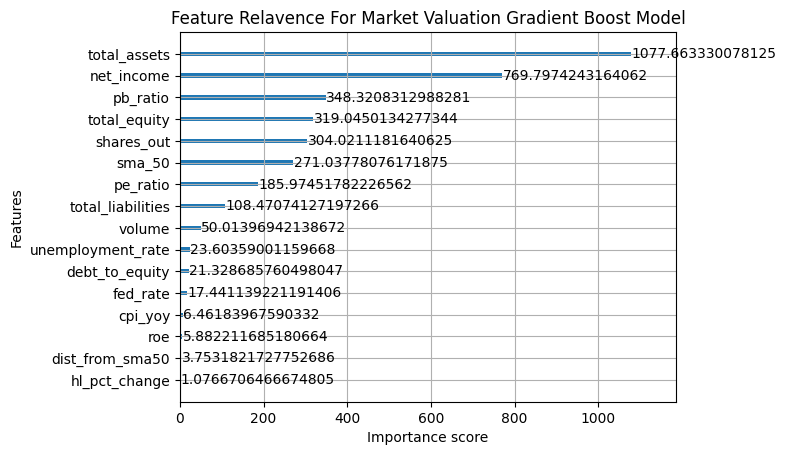

In [2]:
import matplotlib.pyplot as plt

xgb.plot_importance(model, importance_type='gain')
plt.title("Feature Relavence For Market Valuation Gradient Boost Model")

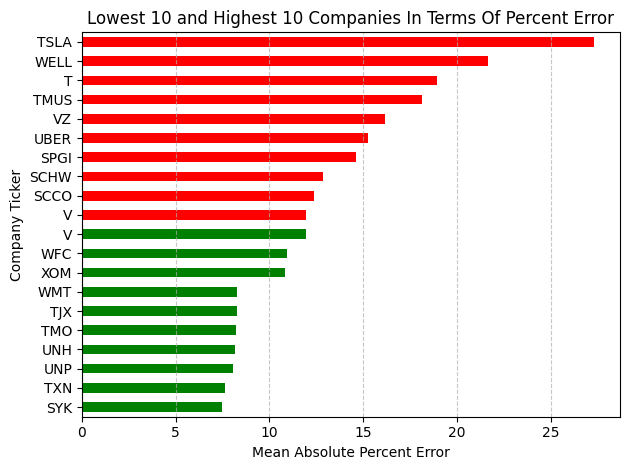

In [4]:
import pandas as pd
import numpy as np

results = pd.read_csv(os.path.join(config.CLEANED_PATH, "xgb_test_results.csv"))

model_performance = results.groupby('ticker')['percent_error'].mean().sort_values()

high_v_low = pd.concat([model_performance.head(10),model_performance.tail(10)])

high_v_low.plot(kind='barh', color=['green']*10 + ['red']*10)

plt.title('Lowest 10 and Highest 10 Companies In Terms Of Percent Error')
plt.xlabel('Mean Absolute Percent Error')
plt.ylabel('Company Ticker')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
